In [1]:
%autosave 60

Autosaving every 60 seconds


## Decision Tree

In [2]:
# https://github.com/JinhangZhu/jinhang.work/blob/master/content/tech/Develop-a-Decision-Tree-in-Python-From-Scratch.md
# Объясняем как работает дерево

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = (X > 5).astype(int).ravel()

In [47]:
# (y)
# |\
# | \
# (y_1)(y_2)

In [48]:
def gini_impurity(y_true_):
    classes, counts = np.unique(y_true_, return_counts=True)

    impurity = 1.0
    for count in counts:
      prob = count / len(y_true_)
      impurity -= prob ** 2

    return impurity

In [49]:
def evaluate_split(X, y, threshold):

  left_indices = X.ravel() <= threshold
  right_indices = ~left_indices

  if np.sum(left_indices) == 0 or np.sum(right_indices) == 0:
    return 1.0

  left_gini = gini_impurity(y[left_indices])
  right_gini = gini_impurity(y[right_indices])

  n_left = np.sum(left_indices)
  n_right = np.sum(right_indices)

  weighted_gini = (n_left * left_gini + n_right * right_gini) / len(y)

  return weighted_gini

In [69]:
def find_best_split(X, y, num_thresholds=100):
  min_val, max_val = X.min(), X.max()
  thresholds = np.linspace(min_val, max_val, num_thresholds)

  results = []
  for threshold in thresholds:
    gini = evaluate_split(X, y, threshold)
    results.append((threshold, gini))

  results_df = pd.DataFrame(results, columns=['Threshold', 'Gini'])

  best_idx = results_df['Gini'].idxmin()
  best_threshold = results_df.loc[best_idx, 'Threshold']
  best_gini = results_df.loc[best_idx, 'Gini']

  return results_df, best_threshold, best_gini

In [70]:
results_df, best_threshold, best_gini = find_best_split(X, y)

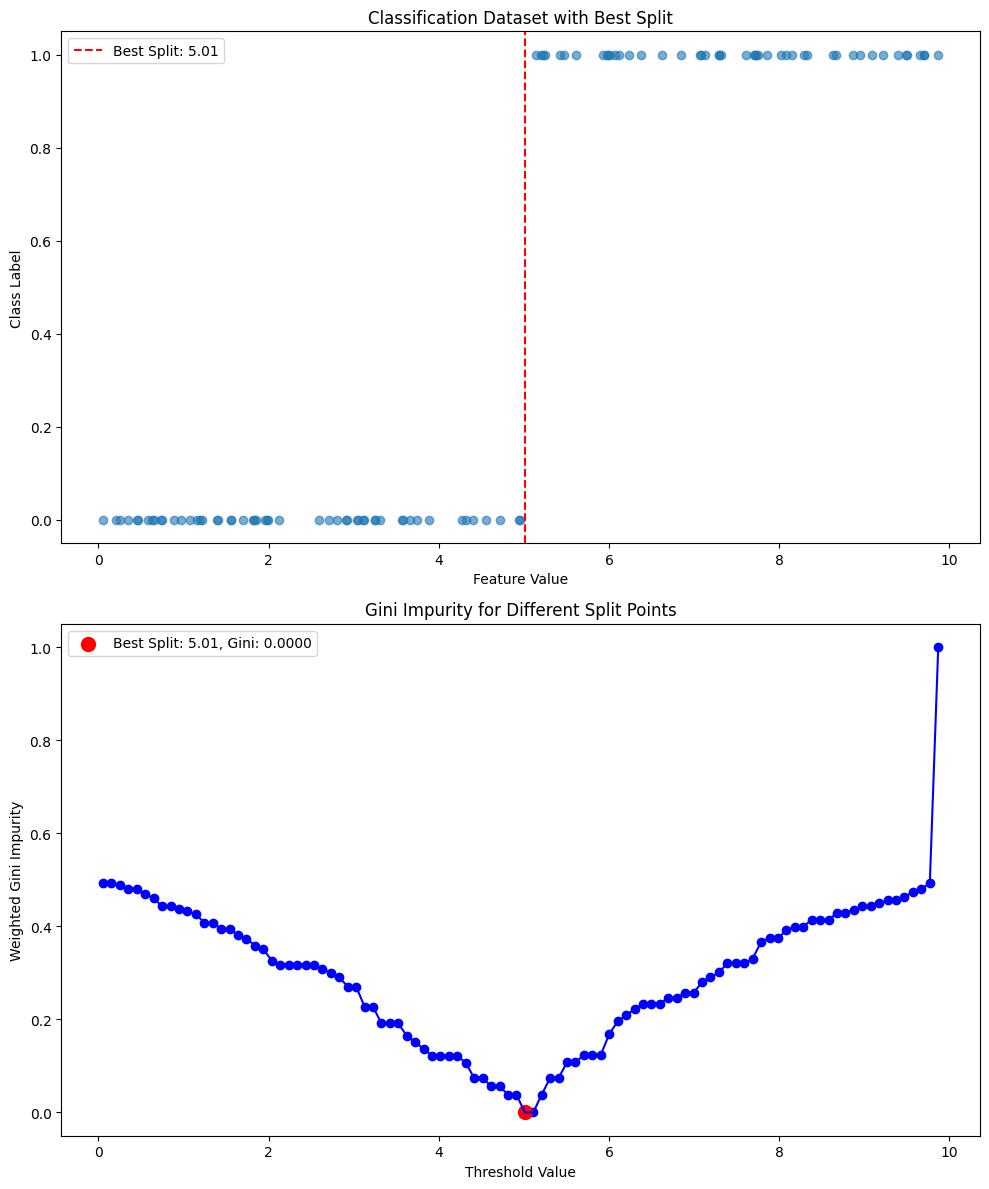

In [71]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

ax1.scatter(X, y, alpha=0.6)
ax1.axvline(x=best_threshold, color='red', linestyle='--',
           label=f'Best Split: {best_threshold:.2f}')
ax1.set_title('Classification Dataset with Best Split')
ax1.set_xlabel('Feature Value')
ax1.set_ylabel('Class Label')
ax1.legend()


ax2.plot(results_df['Threshold'], results_df['Gini'], 'b-')
ax2.scatter(results_df['Threshold'], results_df['Gini'], color='blue')
ax2.scatter(best_threshold, best_gini, color='red', s=100,
           label=f'Best Split: {best_threshold:.2f}, Gini: {best_gini:.4f}')
ax2.set_title('Gini Impurity for Different Split Points')
ax2.set_xlabel('Threshold Value')
ax2.set_ylabel('Weighted Gini Impurity')
ax2.legend()

plt.tight_layout()
plt.show()

In [72]:
print(f"Best threshold: {best_threshold:.4f}")
print(f"Minimum Gini impurity: {best_gini:.4f}")

Best threshold: 5.0116
Minimum Gini impurity: 0.0000


## compare with sklearn

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [60]:
clf = DecisionTreeClassifier(max_depth=1, criterion='gini', random_state=42)
clf = clf.fit(X, y)

In [63]:
sklearn_threshold = clf.tree_.threshold[0]
sklearn_impurity = clf.tree_.impurity[0]
sklearn_impurity_left = clf.tree_.impurity[1]
sklearn_impurity_right = clf.tree_.impurity[2]
n_samples = clf.tree_.n_node_samples[0]
n_left = clf.tree_.n_node_samples[1]
n_right = clf.tree_.n_node_samples[2]

In [64]:
sklearn_weighted_impurity = (n_left * sklearn_impurity_left + n_right * sklearn_impurity_right) / n_samples

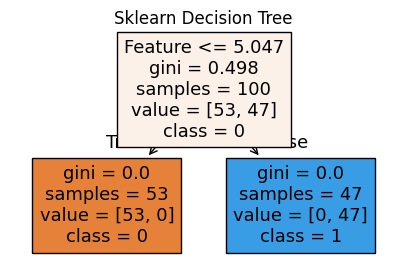

In [67]:
plt.figure(figsize=(5, 3))
plot_tree(clf, filled=True, feature_names=['Feature'], class_names=['0', '1'])
plt.title('Sklearn Decision Tree')
plt.show()

In [73]:
(
    sklearn_threshold,
    sklearn_weighted_impurity
)

(5.047056674957275, 0.0)

In [74]:
print(f"Best threshold: {best_threshold:.4f}")
print(f"Minimum Gini impurity: {best_gini:.4f}")

Best threshold: 5.0116
Minimum Gini impurity: 0.0000


# ml comp 1

In [6]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [7]:
import os
from scipy.stats import zscore

In [8]:
path_files = 'drive/MyDrive/ШАД 2025/'

# 'train_1.csv',
# 'test_1.csv',
# 'train_2.csv',
# 'test_2.csv',

train = pd.read_csv(path_files + 'train_1.csv')
test = pd.read_csv(path_files + 'test_1.csv')

In [9]:
train.shape, test.shape

((786431, 18), (262144, 17))

In [10]:
train.head(1)

,transaction_time,merch,cat_id,amount,name_1,name_2,gender,street,one_city,us_state,post_code,lat,lon,population_city,jobs,merchant_lat,merchant_lon,target
0,2019-12-27 15:21,fraud_Cormier LLC,health_fitness,148.04,Daniel,Martinez,M,8510 Acevedo Burgs,Kent,OR,97033,45.0838,-120.6649,60,Museum education officer,45.042827,-120.709327,0


In [11]:
train['ts_transaction_time'] = pd.to_datetime(train['transaction_time']).values.astype('int64') // 10**9
test['ts_transaction_time'] = pd.to_datetime(test['transaction_time']).values.astype('int64') // 10**9

In [12]:
numeric_features = [
    'amount', 'ts_transaction_time', 'lat', 'lon', 'population_city', 'merchant_lat', 'merchant_lon'
]

cat_columns = [
    'merch', 'cat_id', 'name_1', 'name_2', 'gender', 'street', 'one_city', 'us_state', 'post_code', 'jobs'
]

## Выбросы

In [13]:
# по полю ts_transaction_time (transaction_time) выбросов нет
np.sum(np.abs(zscore(train['ts_transaction_time'].values)) >= 3)

0

amount train 7614 test 2694


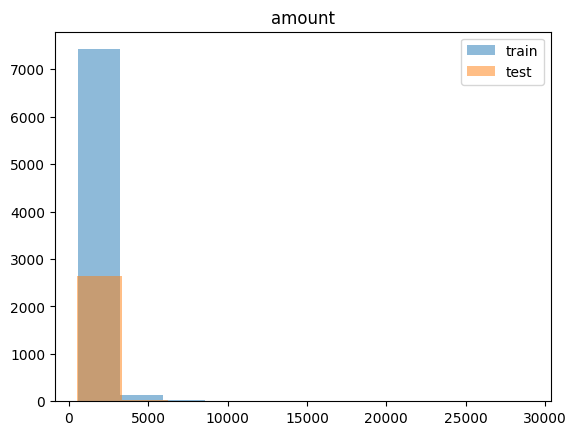

ts_transaction_time train 0 test 0


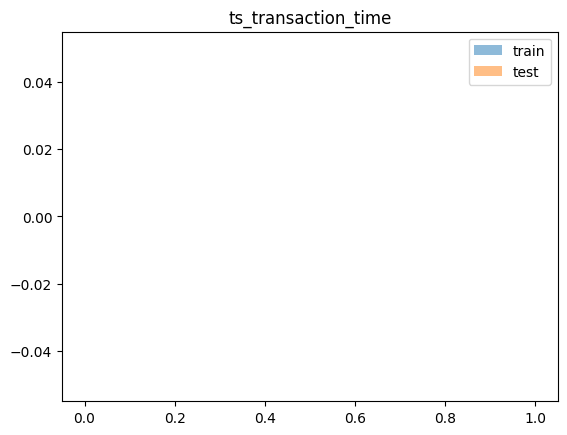

lat train 2804 test 940


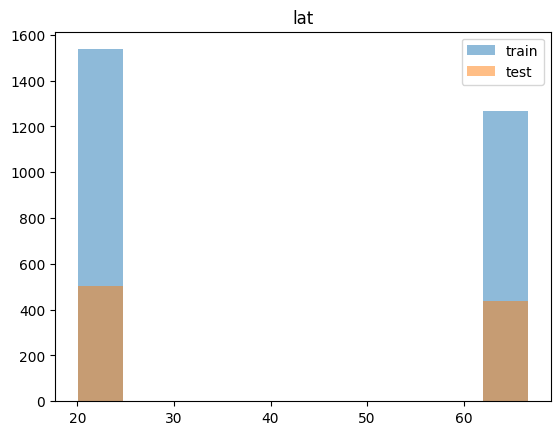

lon train 2804 test 940


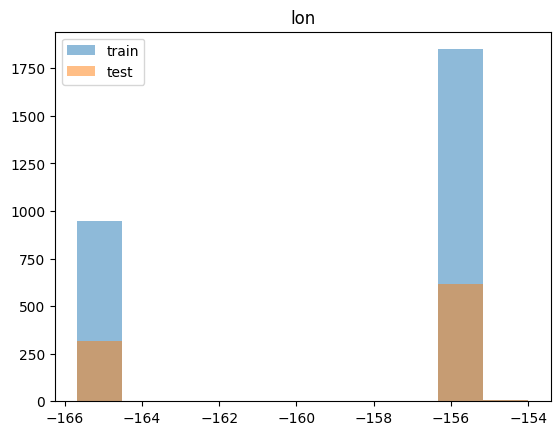

population_city train 20039 test 6572


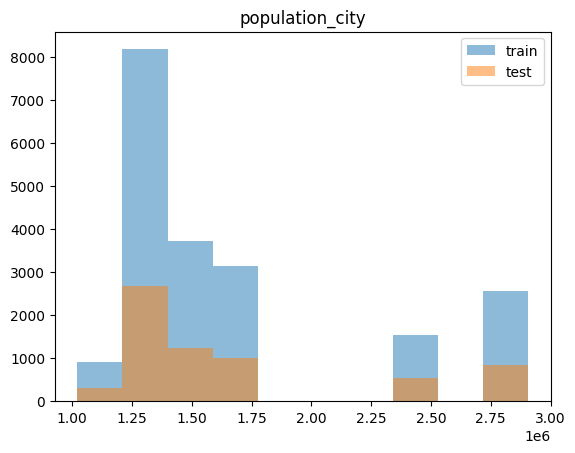

merchant_lat train 2804 test 940


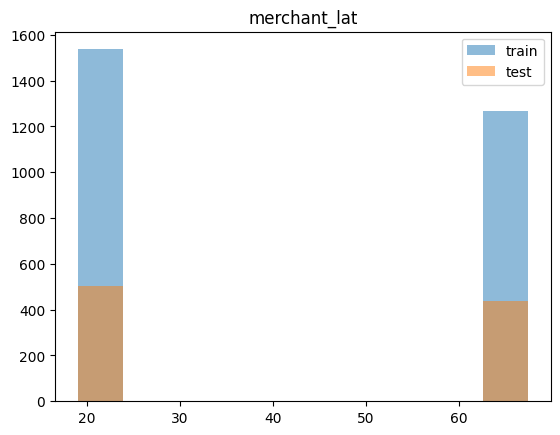

merchant_lon train 2804 test 940


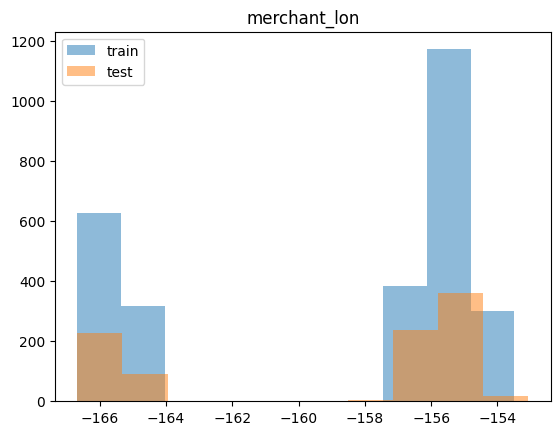

In [14]:
for one_feature in numeric_features:

  mask_outliesr_train = np.abs(zscore(train[one_feature].values)) >= 3
  mask_outliesr_test = np.abs(zscore(test[one_feature].values)) >= 3

  print(
      one_feature,
      'train', sum(mask_outliesr_train),
      'test', sum(mask_outliesr_test),
  )

  plt.hist(train[mask_outliesr_train][one_feature], alpha=0.5, label='train')
  plt.hist(test[mask_outliesr_test][one_feature], alpha=0.5, label='test')
  plt.legend()
  plt.title(one_feature)
  plt.show()

In [50]:
c = 0
for one_feature in cat_columns:
  print(one_feature, train[one_feature].nunique())
  c += train[one_feature].nunique()

merch 693
cat_id 14
name_1 348
name_2 479
gender 2
street 965
one_city 879
us_state 51
post_code 952
jobs 493


In [51]:
print(c)

4876


## Feature Engineering

In [15]:
# pip install category-encoders
# https://www.kaggle.com/code/matleonard/categorical-encodings#CatBoost-Encoding
# https://contrib.scikit-learn.org/category_encoders/catboost.html

In [16]:
import category_encoders as ce

In [17]:
target_enc = ce.CatBoostEncoder(cols=cat_columns)

In [18]:
target_enc = target_enc.fit(train[cat_columns], train['target'])

In [19]:
train = train.join(target_enc.transform(train[cat_columns]).add_suffix('_cb'))
test = test.join(target_enc.transform(test[cat_columns]).add_suffix('_cb'))

In [21]:
import numpy as np
from math import atan2, cos, radians, sin, sqrt


def haversine_distance(lat1: float, lon1: float, lat2: float, lon2: float, n_digits: int = 0) -> float:
    """
        Функция для расчёта расстояния от точки А до Б по прямой

        :param lat1: Широта точки А
        :param lon1: Долгота точки А
        :param lat2: Широта точки Б
        :param lon2: Долгота точки Б
        :param n_digits: Округляем полученный ответ до n знака после запятой
        :return: Дистанция по прямой с точностью до n_digits
    """

    lat1, lon1, lat2, lon2 = round(lat1, 6), round(lon1, 6), round(lat2, 6), round(lon2, 6)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)

    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2

    return round(2 * 6372800 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)), n_digits)  # метры.сантиметры


def bearing_degree(lat1: float, lon1: float, lat2: float, lon2: float, n_digits: int = 0) -> float:
    """
        Функция для расчёта угла между прямой [((lat1, lon1), (lat2, lon2)), (нулевой мередиан)]

        :param lat1: Широта точки А
        :param lon1: Долгота точки А
        :param lat2: Широта точки Б
        :param lon2: Долгота точки Б
        :param n_digits: Округляем полученный ответ до n знака после запятой
        :return: Значение угла с точностью до n_digits
    """

    lat1, lon1 = np.radians(round(lat1, 6)), np.radians(round(lon1, 6))
    lat2, lon2 = np.radians(round(lat2, 6)), np.radians(round(lon2, 6))

    dlon = (lon2 - lon1)
    numerator = np.sin(dlon) * np.cos(lat2)
    denominator = np.cos(lat1) * np.sin(lat2) - (np.sin(lat1) * np.cos(lat2) * np.cos(dlon))

    theta = np.arctan2(numerator, denominator)
    theta_deg = (np.degrees(theta) + 360) % 360

    return round(theta_deg, n_digits)

In [22]:
# 'lat', 'lon'
# 'merchant_lat', 'merchant_lon'

In [23]:
train['bearing_degree_1'] = bearing_degree(train['lat'], train['lon'], train['merchant_lat'], train['merchant_lon'], ).values
test['bearing_degree_1'] = bearing_degree(test['lat'], test['lon'], test['merchant_lat'], test['merchant_lon'], ).values

In [24]:
# TODO:
# углы / расстояния к штатам где много
# - данных / клиентов / покупок / (осторожно: фрода)
# -

In [25]:
train['bearing_degree_2'] = bearing_degree(train['lat'], train['lon'], 0, 0, ).values
test['bearing_degree_2'] = bearing_degree(test['lat'], test['lon'], 0, 0, ).values

train['bearing_degree_3'] = bearing_degree(0, 0, train['merchant_lat'], train['merchant_lon'], ).values
test['bearing_degree_3'] = bearing_degree(0, 0, test['merchant_lat'], test['merchant_lon'], ).values

In [26]:
train['hav_dist_1'] = haversine_distance(train['lat'], train['lon'], train['merchant_lat'], train['merchant_lon'], ).values
test['hav_dist_1'] = haversine_distance(test['lat'], test['lon'], test['merchant_lat'], test['merchant_lon'], ).values

In [27]:
train['hav_dist_2'] = haversine_distance(train['lat'], train['lon'], 0, 0, ).values
test['hav_dist_2'] = haversine_distance(test['lat'], test['lon'], 0, 0, ).values

train['hav_dist_3'] = haversine_distance(0, 0, train['merchant_lat'], train['merchant_lon'], ).values
test['hav_dist_3'] = haversine_distance(0, 0, test['merchant_lat'], test['merchant_lon'], ).values

## Baseline Model

In [28]:
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [29]:
model_features = [
  'amount',
  'bearing_degree_1',
  'bearing_degree_2',
  'bearing_degree_3',
  'cat_id_cb',
  'gender_cb',
  'hav_dist_1',
  'hav_dist_2',
  'hav_dist_3',
  'jobs_cb',
  'lat',
  'lon',
  'merch_cb',
  'merchant_lat',
  'merchant_lon',
  'name_1_cb',
  'name_2_cb',
  'one_city_cb',
  'population_city',
  'post_code_cb',
  'street_cb',
  'us_state_cb',
]

In [30]:
# model = DecisionTreeClassifier(max_depth=5, random_state=15, )
model = LGBMClassifier(n_estimators=50, random_state=14, )

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    train[model_features], train['target'], test_size=0.25, random_state=42,
    stratify=train['target']
)

In [32]:
%%time
model = model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 3378, number of negative: 586445
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.134485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4459
[LightGBM] [Info] Number of data points in the train set: 589823, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005727 -> initscore=-5.156795
[LightGBM] [Info] Start training from score -5.156795
CPU times: user 5.43 s, sys: 53.8 ms, total: 5.48 s
Wall time: 5.46 s


In [33]:
predictions = model.predict_proba(X_test)

In [34]:
predictions = predictions[:, 1]

In [35]:
# TODO: подобрать threshold модели (поменять np.mean(predictions))
predictions_binary = predictions >= np.mean(predictions)

In [36]:
f1_score(y_test, predictions_binary)

0.3692127368626685

## Оценка и Анализ модели

In [37]:
import shap

In [38]:
%%time
shap_values = shap.TreeExplainer(model).shap_values(X_test)

CPU times: user 2min 15s, sys: 171 ms, total: 2min 15s
Wall time: 1min 24s


/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


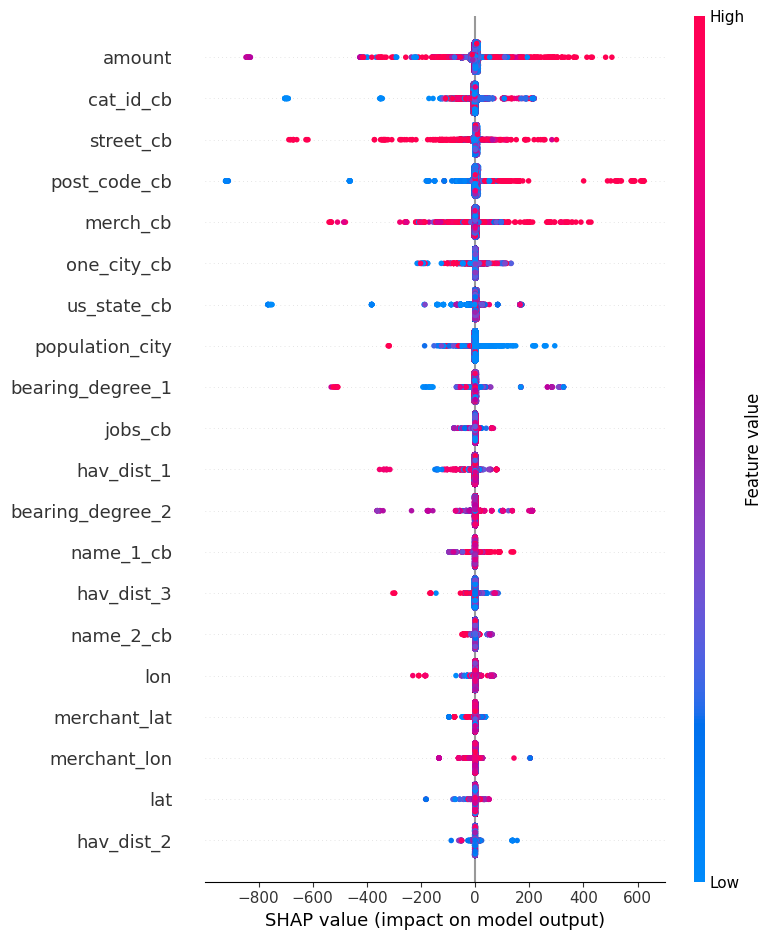

In [39]:
shap.summary_plot(shap_values, X_test)